# Example 6: GNSS Sidelobe Pseudorange + TDCP ODTS with an EKF

This notebook estimates the trajectory and clock state of a lunar-orbiting receiver from
**cislunar GNSS sidelobe pseudorange** and **time-differenced carrier phase (TDCP)**
measurements, tracked through a UDU Extended Kalman Filter (EKF). It follows the staged
"precompute, then filter" pipeline used in `projects/GNSS_Filtering` (see its
`README.md`), driven here through Python bindings for the same C++
`lupnt::LunarGnssODTSSimulation` engine so the whole example lives in one notebook:

1. **Precompute GNSS link geometry** — propagate the truth ELFO trajectory, build the GPS
   constellation from SP3/ANTEX products, and solve link visibility/C-N0 with the GPS
   transmit antenna gain pattern. Because the receiver is at lunar distance, well outside
   the Earth-pointed GPS main beam, nearly every tracked satellite is seen through an
   **antenna sidelobe** (Example 5 visualizes this geometry in detail).
2. **Precompute plasmaspheric delay** with the GCPM/IRI2007 ray tracer (mirrors
   `projects/GNSS_Filtering/precompute_delays.py`).
3. **Run the EKF** — generate noisy pseudorange and TDCP observations and estimate
   receiver position, velocity, clock bias, and clock drift.

Both precompute stages write CSV files to `ex6_gnss_odts_data/` next to this notebook;
re-running the notebook reuses them instead of regenerating, since ray tracing is the slow
step. Delete that directory to force a clean regeneration.

**Relativity and plasma delay.** Truth pseudoranges include the Sun's Shapiro delay and
the GCPM/IRI2007 plasmaspheric delay; both truth and filter dynamics apply a Moon-centered
relativistic clock-rate correction (`JointOrbitClockDynamics`). The filter does *not*
model the plasma delay directly — representing an unmodeled space-weather environment —
and instead absorbs the mismatch through pseudorange measurement-noise inflation.

**TDCP needs extra care.** Naively differencing two epochs' carrier-phase measurements
produces a "new" observation whose noise is correlated with the information the filter
already used to estimate the previous epoch's state (see arXiv:2601.16393 for a detailed
treatment). This notebook's filter follows the same state-augmentation ("stochastic
cloning") approach explored in `projects/Plasmasphere_Delay_Filtering`
(`src/augmented_state_ekf.cc`): when `use_tdcp` is enabled, `LunarGnssODTSSimulation`
carries an augmented state `[x_k, x_{k-1}]` through a UDU stochastic-cloning EKF, so the
TDCP measurement's Jacobian and cross-covariance terms correctly reference both epochs
instead of treating the difference as an independent, current-epoch-only observation.

**A second, easy-to-miss form of "extra care": TDCP noise must be inflated past raw
carrier-tracking precision.** Raw carrier-phase tracking noise is on the order of a
centimeter, and `LunarGnssODTSConfig.tdcp_sigma_m` defaults to a similarly tight `0.02` m.
Feeding that straight into the EKF made it diverge in every configuration tested while
developing this notebook — even a single, cleanly tracked satellite with no plasma delay
at all. Instrumenting `UDUStochasticCloningEKF`'s sequential (Carlson/UD) measurement
update showed why: with `tdcp_sigma_m=0.02`, a single TDCP row produced Kalman gains with
`|K|` near 6 and ~35 m corrections *every epoch*, because the filter's own dynamics model
(12x12 truth-approximating Moon gravity, no SRP) cannot match the 20x20 truth trajectory
to centimeter precision over even a 1-second step. A TDCP sigma that tight tells the
filter "trust this over your own dynamics almost completely," so it chases ordinary
truth/filter model mismatch as if it were real state error every single epoch, and the
resulting bad corrections compound. Inflating `tdcp_sigma_m` to `0.5` m — still far
tighter than the pseudorange noise floor, but loose enough to tolerate the dynamics
model's real fidelity — fixes this cleanly (position error converges to ~25-50 m instead
of diverging past 1 km). This is exactly the kind of TDCP pitfall arXiv:2601.16393
discusses: a differenced carrier-phase measurement is deceptively precise-looking, and an
EKF that takes that precision at face value against an imperfect dynamics model will
diverge.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pylupnt as pnt

[00.00][PyLuPNT] Initializing


## 1. Simulation Configuration

`LunarGnssODTSConfig` mirrors the YAML schema in
`projects/GNSS_Filtering/gnss_filtering_config.yaml`, built directly in Python here. The
truth receiver orbit is the same ELFO family used in Example 5. The sidelobe link budget
(`design.*`) matches the `lunar_gnss_link_budget` entry in
`projects/GNSS_Filtering/gnss_designs.yaml`: it loads the GPS transmit antenna gain
pattern (`setup_transmitters=True`) and derives measurement sigmas from C/N0
(`use_cn0_measurement_sigmas=True`) instead of assuming fixed noise. The 2025-01-01 epoch
matches the IGS combined SP3 product already cached under
`LuPNT_data/ephemeris/gnsslibpy/sp3/`, so no network download is needed.

The CN0 floor is set lower than `gnss_designs.yaml`'s 15 dB-Hz (a value tuned for longer
Monte Carlo runs where geometry changes enough over time to be observable through a single
satellite at a time). Over this notebook's single 3-minute snapshot the receiver's sidelobe
geometry barely changes, so a higher floor tracks only one satellite for the entire window
— not enough range diversity for a meaningful position fix. 10 dB-Hz instead keeps
4-5 satellites in view simultaneously (still every one of them received off the GPS
transmit antenna's main beam, i.e. through a sidelobe), which is enough for the classic
GNSS 4-satellite position+clock-bias solution every epoch.

In [2]:
DATA_DIR = Path("LuPNT_data")
OUTPUT_DIR = Path("ex6_gnss_odts_data")
OUTPUT_DIR.mkdir(exist_ok=True)

cfg = pnt.LunarGnssODTSConfig()

# --- Simulation timing: 3-minute, 1 Hz run (same default as projects/GNSS_Filtering) ---
cfg.seed = 42
cfg.monte_carlo_runs = 1
cfg.start_epoch_utc = "2025-01-01T00:00:00"
cfg.duration_s = 180.0
cfg.dt_s = 1.0
cfg.ephemeris_dt_s = 30.0
cfg.receiver_app.rate_hz = 1.0

cfg.output_dir = str(OUTPUT_DIR.resolve())
cfg.links_file = str((OUTPUT_DIR / "precomputed_links.csv").resolve())
cfg.delays_file = str((OUTPUT_DIR / "precomputed_delays.csv").resolve())

# --- Truth receiver orbit: ELFO, same family as Example 5 (a=6541.4 km, e=0.6) ---
cfg.receiver_a_m = 6541.4e3
cfg.receiver_ecc = 0.6
cfg.receiver_inc_rad = 65.5 * pnt.RAD
cfg.receiver_raan_rad = 60.0 * pnt.RAD
cfg.receiver_argp_rad = 90.0 * pnt.RAD
cfg.receiver_mean_anomaly_rad = 0.0
cfg.clock_bias_s = 2.0e-6
cfg.clock_drift_sps = 1.0e-10

# --- GPS constellation from local SP3/ANTEX (2025-01-01 IGS combined product).
# `auto_select_sp3` only takes effect through the YAML config loader, not this
# struct-based path, so the covering SP3 files are listed explicitly here. ---
sp3_dir = (DATA_DIR / "ephemeris" / "gnsslibpy" / "sp3").resolve()
cfg.constellation.sp3_directory = str(sp3_dir)
cfg.constellation.antex_file = str((DATA_DIR / "gnss" / "igs20.atx").resolve())
cfg.constellation.auto_select_sp3 = False
cfg.constellation.sp3_files = [
    str(sp3_dir / "IGS0OPSFIN_20243660000_01D_15M_ORB.SP3"),  # 2024-12-31 (margin before)
    str(sp3_dir / "IGS0OPSFIN_20250010000_01D_15M_ORB.SP3"),  # 2025-01-01 (covers the run)
]
cfg.constellation.use_all_gps = True
cfg.constellation.include_galileo = False  # this SP3 product only carries GPS

# --- Sidelobe link budget ("lunar_gnss_link_budget" design) ---
cfg.design.receiver_params.Bp = 1.0    # carrier loop noise bandwidth [Hz]
cfg.design.receiver_params.T = 0.02    # integration time [s]
cfg.design.receiver_params.b = 2.0     # front-end bandwidth factor
cfg.design.receiver_params.Bn = 0.7    # code loop noise bandwidth [Hz]
cfg.design.receiver_params.Bf = 0.2    # frequency loop noise bandwidth [Hz]
cfg.design.receiver_params.D = 0.1     # early-late correlator spacing [chip]
cfg.design.setup_transmitters = True          # load GPS TX antenna gain patterns
cfg.design.apply_cn0_threshold = True         # drop links below the CN0 floor
cfg.design.cn0_threshold_dbhz = 10.0          # weak-signal sidelobe floor (see note above)
cfg.design.use_cn0_measurement_sigmas = True  # derive sigma_pseudorange from C/N0

# --- Force model: 20x20 Moon gravity truth / 12x12 filter, Earth+Sun third-body,
# Moon-centered relativistic clock-rate correction applied to both truth and filter ---
cfg.moon_gravity_degree_truth, cfg.moon_gravity_order_truth = 20, 20
cfg.moon_gravity_degree_filter, cfg.moon_gravity_order_filter = 12, 12
cfg.include_earth = True
cfg.include_sun = True
cfg.use_relativity = True

# --- Measurements: sidelobe pseudorange + TDCP (no Doppler) ---
cfg.use_pseudorange = True
cfg.use_doppler = False
cfg.use_tdcp = True
cfg.pseudorange_sigma_m = 2.0
cfg.carrier_phase_sigma_m = 0.01
# tdcp_sigma_m inflated well past raw carrier-tracking noise (~cm) -- see note above
# the config block on why a several-cm-per-second TDCP sigma makes the UDU
# stochastic-cloning EKF diverge here.
cfg.tdcp_sigma_m = 0.5

# --- Plasmaspheric delay: GCPM/IRI2007 ray trace, truth-only. Left unmodeled in the
# filter and instead absorbed through pseudorange measurement-noise inflation. ---
cfg.plasma.simulate_truth = True
cfg.plasma.model_in_filter = False
cfg.plasma.filter_pseudorange_noise_inflation_m = 0.75

# --- Filter tuning: initial uncertainty and process noise ---
cfg.initial_position_sigma_m = 20.0
cfg.initial_velocity_sigma_mps = 0.02
cfg.initial_clock_bias_sigma_s = 1.0e-6
cfg.initial_clock_drift_sigma_sps = 1.0e-11
cfg.process_accel_sigma_mps2 = 1.0e-7
cfg.process_clock_bias_sigma_s_sqrt_s = 1.0e-11
cfg.process_clock_drift_sigma_sps_sqrt_s = 1.0e-13
cfg.integration_step_s = 20.0

sim = pnt.LunarGnssODTSSimulation(cfg)
print(f"Configured {cfg.duration_s:.0f}-s run at {cfg.receiver_app.rate_hz:.0f} Hz "
      f"starting {cfg.start_epoch_utc} (TDCP {'on' if cfg.use_tdcp else 'off'})")
print(f"Data directory: {OUTPUT_DIR.resolve()}")

Configured 180-s run at 1 Hz starting 2025-01-01T00:00:00 (TDCP on)
Data directory: /home/kiiyama/LuPNT/python/examples/ex6_gnss_odts_data


## 2. Stage 1 — Precompute GNSS Link Geometry

`sim.precompute()` propagates the truth ELFO trajectory, builds the GPS constellation,
solves receiver-satellite visibility/light time, and writes every tracked
receiver-satellite-frequency link to `config.links_file` with its C/N0 and geometry —
delay columns are written as zero at this stage. The C++ side caches this step by
fingerprinting the config, so re-running this cell after the first time is a fast no-op.

In [3]:
t0 = time.time()
sim.precompute()
print(f"precompute() took {time.time() - t0:.1f} s")

links = pd.read_csv(cfg.links_file)
print(f"{len(links)} receiver-satellite-frequency links across "
      f"{links['epoch_index'].nunique()} epochs "
      f"({links.groupby('epoch_index').size().mean():.1f} links/epoch on average)")
links.head()

precompute() took 0.0 s
[00.08][LunarGnssODTS] Using cached GNSS link precompute: /home/kiiyama/LuPNT/python/examples/ex6_gnss_odts_data/precomputed_links.csv
802 receiver-satellite-frequency links across 181 epochs (4.4 links/epoch on average)


,link_id,epoch_index,t_tdb,t_utc,gnss_const_id,gnss_const,prn,frequency_id,frequency,rx_x_ecef_m,...,cn0_dbhz,ionosphere_plasma_delay_m,tecu,tec_delay_m,second_delay_m,third_delay_m,dist_bend_m,tec_delay_bend_m,max_sep_line_m,final_pos_err_m
0,0,0,7.889617e+08,788961600.0,0,GPS,2,0,L1,-3.310448e+08,...,16.615265,0,0,0,0,0,0,0,0,0
1,1,0,7.889617e+08,788961600.0,0,GPS,4,0,L1,-3.310448e+08,...,12.131754,0,0,0,0,0,0,0,0,0
2,2,0,7.889617e+08,788961600.0,0,GPS,21,0,L1,-3.310448e+08,...,22.786481,0,0,0,0,0,0,0,0,0
3,3,0,7.889617e+08,788961600.0,0,GPS,27,0,L1,-3.310448e+08,...,14.159391,0,0,0,0,0,0,0,0,0
4,4,1,7.889617e+08,788961601.0,0,GPS,2,0,L1,-3.310524e+08,...,16.626603,0,0,0,0,0,0,0,0,0


## 3. Stage 2 — Precompute Plasmaspheric Delay (GCPM/IRI2007 Ray Trace)

This mirrors `projects/GNSS_Filtering/precompute_delays.py`: for every non-occulted link,
`pnt.trace_ray` integrates the GCPM/IRI2007 electron-density model along the
transmitter-receiver line of sight and returns the total electron content (TEC) delay plus
higher-order (2nd/3rd) ionospheric terms. This is the slow step (one ray trace per link),
so results are cached to `config.delays_file` and reused on subsequent runs.

In [4]:
FREQ_HZ = {"L1": 1575.42e6, "L2": 1227.60e6, "L5": 1176.45e6}
EARTH_RADIUS_KM = 6371.2

delays_path = Path(cfg.delays_file)
if delays_path.exists():
    print(f"Reusing cached plasma delays: {delays_path}")
    delays = pd.read_csv(delays_path)
else:
    pnt.set_iri_model("IRI2007")
    rt_config = pnt.RayTraceConfig()
    rt_config.step_size = cfg.plasma.raytrace_step_size_km
    rt_config.correction = cfg.plasma.raytrace_correction
    rt_config.fine_correction = cfg.plasma.raytrace_fine_correction
    rt_config.cutoff_r = cfg.plasma.raytrace_cutoff_radius_re * EARTH_RADIUS_KM
    rt_config.gradn_dx = cfg.plasma.raytrace_gradient_step_km
    rt_config.integ_method = cfg.plasma.raytrace_integrator
    rt_config.correction_method = cfg.plasma.raytrace_correction_method
    rt_config.kp = cfg.plasma.raytrace_kp
    rt_config.use_fortran_gcpm = cfg.plasma.raytrace_use_fortran_gcpm
    rt_config.corr_tol = cfg.plasma.raytrace_correction_tolerance_m
    rt_config.compute_higher_order = cfg.plasma.raytrace_compute_higher_order
    rt_config.use_adaptive_step = cfg.plasma.raytrace_use_adaptive_step
    rt_config.straight_ray = cfg.plasma.raytrace_straight_ray

    occulted = links["tangent_altitude_m"] < 0.0
    rays = links.loc[~occulted]
    if occulted.any():
        print(f"Skipping {int(occulted.sum())} Earth-occulted links")
    print(f"Ray-tracing {len(rays)} links...")

    idxs, tecu_l, tec_l, second_l, third_l, total_l = [], [], [], [], [], []
    t0 = time.time()
    for k, (idx, row) in enumerate(rays.iterrows(), start=1):
        rt_config.freq_Hz = FREQ_HZ.get(str(row["frequency"]), FREQ_HZ["L1"])
        tx_km = np.array([row["tx_x_ecef_m"], row["tx_y_ecef_m"], row["tx_z_ecef_m"]]) / 1e3
        rx_km = np.array([row["rx_x_ecef_m"], row["rx_y_ecef_m"], row["rx_z_ecef_m"]]) / 1e3
        profile = pnt.trace_ray(float(row["t_utc"]), tx_km, rx_km, rt_config, False, False)
        tec_m = float(profile.tec_delay_m)
        higher_m = (float(profile.second_delay_m) + float(profile.third_delay_m)
                    if rt_config.compute_higher_order else 0.0)
        idxs.append(idx)
        tecu_l.append(float(profile.tecu))
        tec_l.append(tec_m)
        second_l.append(float(profile.second_delay_m))
        third_l.append(float(profile.third_delay_m))
        total_l.append(tec_m + higher_m)
        if k % 200 == 0 or k == len(rays):
            print(f"  {k}/{len(rays)} rays traced ({time.time() - t0:.0f}s elapsed)")

    delay_cols = ["tecu", "tec_delay_m", "second_delay_m", "third_delay_m",
                  "ionosphere_plasma_delay_m"]
    delays = links.copy()
    delays[delay_cols] = delays[delay_cols].astype(float)  # C++ writer left these as int 0
    delays.loc[idxs, "tecu"] = tecu_l
    delays.loc[idxs, "tec_delay_m"] = tec_l
    delays.loc[idxs, "second_delay_m"] = second_l
    delays.loc[idxs, "third_delay_m"] = third_l
    delays.loc[idxs, "ionosphere_plasma_delay_m"] = total_l
    delays.to_csv(delays_path, index=False)
    print(f"Wrote {delays_path} in {time.time() - t0:.1f} s")

print(f"Plasma delay range: {delays['ionosphere_plasma_delay_m'].min():.2f} - "
      f"{delays['ionosphere_plasma_delay_m'].max():.2f} m")

Reusing cached plasma delays: /home/kiiyama/LuPNT/python/examples/ex6_gnss_odts_data/precomputed_delays.csv
Plasma delay range: 0.02 - 2.82 m


### Sanity check: delay vs. ray tangent altitude

The plasmaspheric delay should fall off roughly monotonically as the signal path's tangent
point rises away from the denser plasmasphere near Earth.

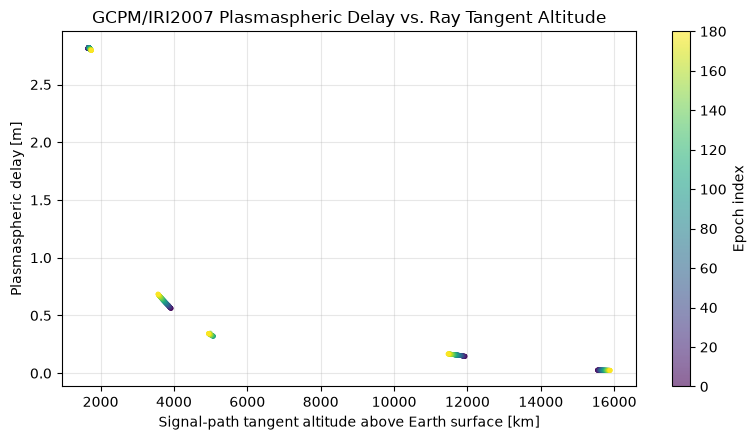

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sc = ax.scatter(delays["tangent_altitude_m"] / 1e3, delays["ionosphere_plasma_delay_m"],
                 s=6, c=delays["epoch_index"], cmap="viridis", alpha=0.6)
ax.set_xlabel("Signal-path tangent altitude above Earth surface [km]")
ax.set_ylabel("Plasmaspheric delay [m]")
ax.set_title("GCPM/IRI2007 Plasmaspheric Delay vs. Ray Tangent Altitude")
plt.colorbar(sc, ax=ax, label="Epoch index")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Run the EKF

`sim.run()` reads `config.delays_file` (since `plasma.simulate_truth=True`), builds noisy
truth pseudorange and TDCP observations, and runs the UDU stochastic-cloning EKF (because
`use_tdcp=True`) over the full receiver-app schedule. It writes
`trajectory_mc0.csv` and `summary.csv` under `config.output_dir` and returns one
`LunarGnssODTSSummary` per Monte Carlo run.

In [6]:
t0 = time.time()
sim.run()
print(f"run() took {time.time() - t0:.1f} s")

summary = sim.get_summaries()[0]
print(f"Final position error:    {summary.final_position_error_m:8.3f} m")
print(f"Final velocity error:    {summary.final_velocity_error_mps * 1e3:8.3f} mm/s")
print(f"Final clock bias error:  {summary.final_clock_bias_error_m * 1e2:8.3f} cm")
print(f"Final clock drift error: {summary.final_clock_drift_error_mps * 1e3:8.3f} mm/s")
print(f"RMS position error:      {summary.rms_position_error_m:8.3f} m")
print(f"RMS velocity error:      {summary.rms_velocity_error_mps * 1e3:8.3f} mm/s")

traj = pd.read_csv(Path(cfg.output_dir) / "trajectory_mc0.csv")
traj["t_min"] = traj["t"] / 60.0
traj.head()

run() took 0.6 s
Final position error:      23.740 m
Final velocity error:      33.832 mm/s
Final clock bias error:  1166.612 cm
Final clock drift error:    1.499 mm/s
RMS position error:        13.702 m
RMS velocity error:       142.369 mm/s


,mc,t,receiver_clock_s,pos_error_m,vel_error_mps,x_error_m,y_error_m,z_error_m,vx_error_mps,vy_error_mps,...,ndot_3sigma_mps,clock_bias_3sigma_m,clock_drift_3sigma_mps,srp_coeff_est_m2_kg,srp_coeff_error_m2_kg,srp_coeff_3sigma_m2_kg,num_channels,num_tracked_satellites,num_measurements,t_min
0,0,0,0.000002,23.4545,0.041010,11.06030,-9.63389,18.3022,0.040219,-0.007852,...,0.060000,65.6434,0,NaN,NaN,NaN,4,4,4,0.000000
1,0,1,1.000000,22.7235,0.074075,10.84510,-9.47290,17.5786,0.057332,-0.042543,...,0.059897,62.8173,0,NaN,NaN,NaN,4,4,8,0.016667
2,0,2,2.000000,22.6251,0.071057,10.74790,-9.54550,17.4717,0.055952,-0.039797,...,0.059796,61.8460,0,NaN,NaN,NaN,4,4,8,0.033333
3,0,3,3.000000,21.0588,0.048158,10.05970,-9.14914,16.0801,0.044656,-0.016934,...,0.059696,61.3544,0,NaN,NaN,NaN,4,4,8,0.050000
4,0,4,4.000000,21.1523,0.034313,9.50221,-9.48267,16.3465,0.033146,0.006448,...,0.059596,61.0576,0,NaN,NaN,NaN,4,4,8,0.066667


## 5. Position Error in the RTN Frame, with 3-sigma Bounds

`r`/`t`/`n` are the radial/transverse/normal components of the position error; the shaded
band is the filter's own formal 3-sigma envelope (`*_3sigma_m` columns), computed from the
EKF covariance at each epoch.

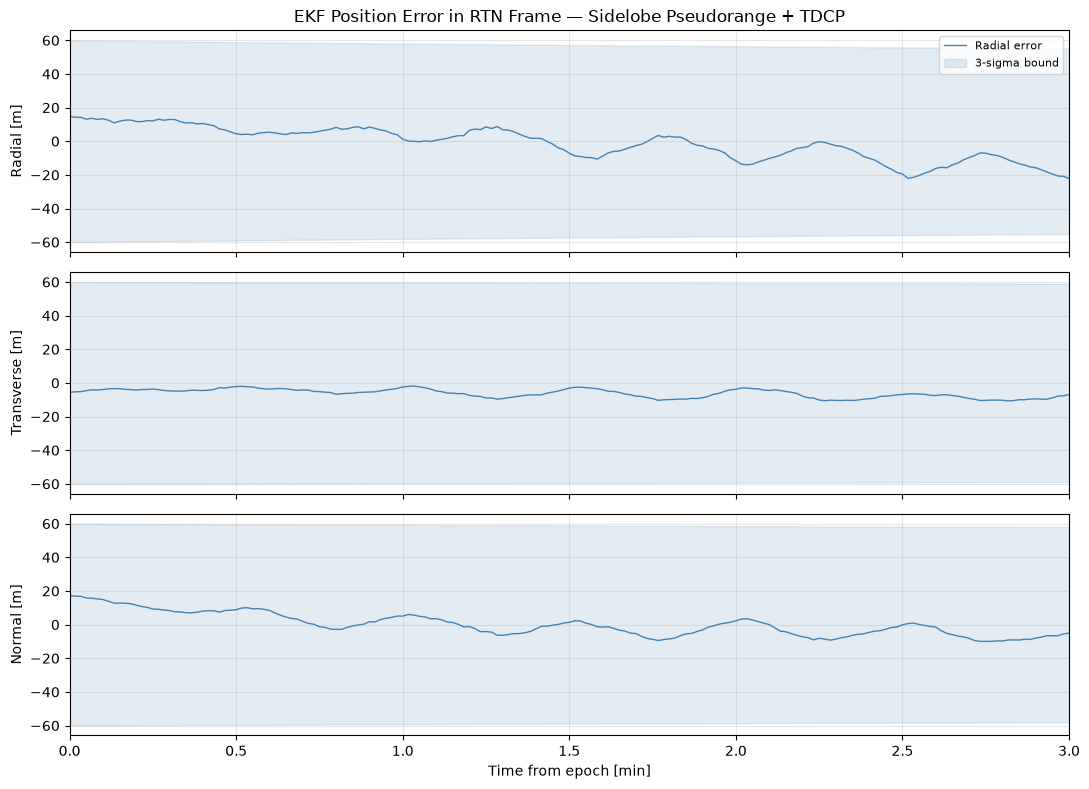

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, (key, name) in zip(axes, [("r", "Radial"), ("t", "Transverse"), ("n", "Normal")]):
    err = traj[f"{key}_error_m"]
    sig = traj[f"{key}_3sigma_m"]
    ax.plot(traj["t_min"], err, color="steelblue", lw=1.0, label=f"{name} error")
    ax.fill_between(traj["t_min"], -sig, sig, color="steelblue", alpha=0.15,
                     label="3-sigma bound")
    ax.set_ylabel(f"{name} [m]")
    ax.grid(True, alpha=0.3)
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("EKF Position Error in RTN Frame — Sidelobe Pseudorange + TDCP")
axes[-1].set_xlabel("Time from epoch [min]")
axes[-1].set_xlim(0, traj["t_min"].max())
plt.tight_layout()
plt.show()

## 6. Clock Bias and Drift Error

Clock errors are reported in range-equivalent units (`c * dt`), matching the pseudorange
measurement's own units.

**Known limitation: the clock *drift* 3-sigma bound is not reliable.** Clock bias's formal
3-sigma bound is well-behaved (the shaded band below tracks the actual error). Clock
drift's is not: `LunarGnssODTSSimulation` hardcodes `ClockBiasUnit::SECONDS`, which puts
position (~10&sup2; m&sup2;), clock bias (~10&#8315;&sup1;&sup2; s&sup2;), and clock drift
(~10&#8315;&sup2;&sup2; (s/s)&sup2;) variances in the *same* covariance matrix spanning
~24 orders of magnitude. That is a severe conditioning problem for the UD/Carlson
factorization the EKF uses, and empirically the drift diagonal collapses to exactly zero
after only a handful of updates — reproducible with or without TDCP, and across initial
drift-uncertainty values from `1e-11` to `1e-6`, so it is unrelated to the TDCP tuning
above. The drift *error* itself stays small and bounded (not shown as diverging), just its
reported uncertainty is untrustworthy — so the plot below omits the drift 3-sigma shading
rather than show a misleadingly tight (zero-width) band.

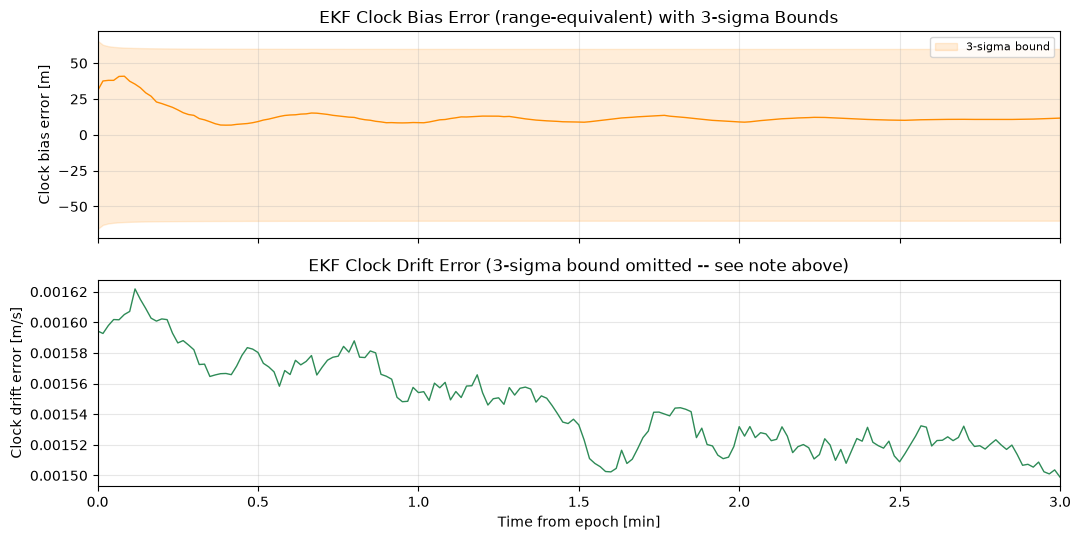

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)

axes[0].plot(traj["t_min"], traj["clock_bias_error_m"], color="darkorange", lw=1.0)
axes[0].fill_between(traj["t_min"], -traj["clock_bias_3sigma_m"], traj["clock_bias_3sigma_m"],
                      color="darkorange", alpha=0.15, label="3-sigma bound")
axes[0].set_ylabel("Clock bias error [m]")
axes[0].set_title("EKF Clock Bias Error (range-equivalent) with 3-sigma Bounds")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(True, alpha=0.3)

# No 3-sigma shading here -- see the markdown note above on why clock_drift_3sigma_mps
# is not trustworthy (covariance conditioning, unrelated to TDCP).
axes[1].plot(traj["t_min"], traj["clock_drift_error_mps"], color="seagreen", lw=1.0)
axes[1].set_ylabel("Clock drift error [m/s]")
axes[1].set_title("EKF Clock Drift Error (3-sigma bound omitted -- see note above)")
axes[1].set_xlabel("Time from epoch [min]")
axes[1].set_xlim(0, traj["t_min"].max())
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Sidelobe Tracking and TDCP Contribution

`num_tracked_satellites` is the number of distinct GPS satellites tracked via sidelobe
reception at each epoch; `num_measurements` is the total measurement-row count fed to the
filter that epoch (pseudorange rows plus one TDCP row per continuously tracked link). The
first epoch has no TDCP rows since there is no previous epoch to difference against.

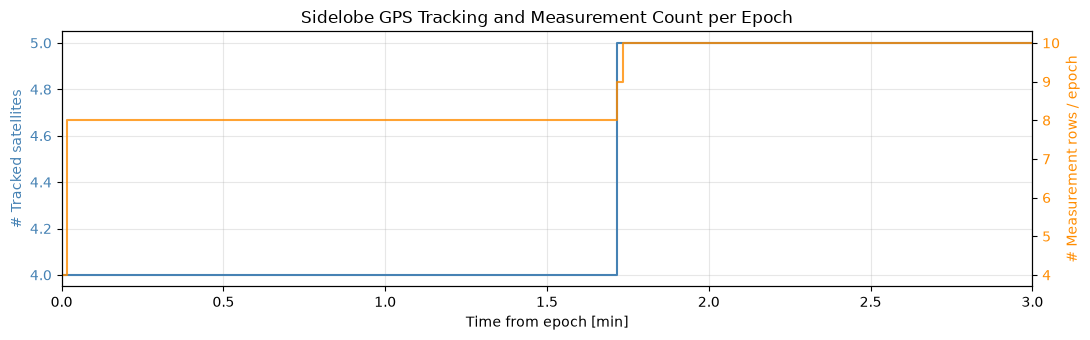

Epochs with at least one TDCP row: 180/181


In [9]:
fig, ax1 = plt.subplots(figsize=(11, 3.5))
ax1.step(traj["t_min"], traj["num_tracked_satellites"], where="post", color="steelblue",
          label="Tracked GPS satellites (sidelobe)")
ax1.set_xlabel("Time from epoch [min]")
ax1.set_ylabel("# Tracked satellites", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xlim(0, traj["t_min"].max())

ax2 = ax1.twinx()
ax2.step(traj["t_min"], traj["num_measurements"], where="post", color="darkorange",
          alpha=0.8, label="Measurement rows (pseudorange + TDCP)")
ax2.set_ylabel("# Measurement rows / epoch", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax1.set_title("Sidelobe GPS Tracking and Measurement Count per Epoch")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_tdcp_epochs = int((traj["num_measurements"] > traj["num_tracked_satellites"]).sum())
print(f"Epochs with at least one TDCP row: {n_tdcp_epochs}/{len(traj)}")

## 8. Summary

- Stage 1/2 data products are cached in `ex6_gnss_odts_data/`
  (`precomputed_links.csv`, `precomputed_delays.csv`, `trajectory_mc0.csv`,
  `summary.csv`) — delete that directory to force a full regeneration.
- The filter tracks GPS satellites almost entirely through **antenna sidelobes**, since
  the ELFO receiver sits well outside the Earth-pointed GPS main beam.
- Plasmaspheric delay is modeled in the truth measurements (GCPM/IRI2007) but left
  unmodeled in the filter, mirroring `projects/GNSS_Filtering`'s
  `plasma.model_in_filter: false` default.
- TDCP rows are formed with a UDU stochastic-cloning EKF carrying `[x_k, x_(k-1)]`,
  following the state-augmentation approach in
  `projects/Plasmasphere_Delay_Filtering/src/augmented_state_ekf.cc` and arXiv:2601.16393.
- For a full Monte Carlo sweep over many runs/designs instead of a single illustrative
  run, see the staged pipeline in `projects/GNSS_Filtering` (`pixi run run-gnss-pipeline`).